01. Exploratory Data Analysis (EDA) & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Импортируем наши функции
import sys
sys.path.append('../src')
from preprocessing import preprocess_pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

### 1. Загрузка данных и проверка на чистоту
В описании датасета заявляено, что он очищен и готов к ML. Убедимся в этом.

In [2]:
df_raw = pd.read_csv('../data/raw/sleep_health_dataset.csv')
print(f"Размер исходного датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов.")

# Проверка на пропуски 
missing_values = df_raw.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_values}")

# Проверка на дубликаты
duplicates = df_raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

if missing_values == 0:
    print("-> Датасет абсолютно чистый, удаление пропусков не требуется.")


Размер исходного датасета: 100000 строк, 32 столбцов.
Общее количество пропущенных значений: 0
Количество полных дубликатов: 0
-> Датасет абсолютно чистый, удаление пропусков не требуется.


**Вывод:** Данные не содержат пропусков и дублей. Классическая импутация здесь не требуется.

### 2. Анализ выбросов (Outliers)
Построим Boxplot для числовых признаков ДО обработки, чтобы проверить наличие или отсутствие выбросов.

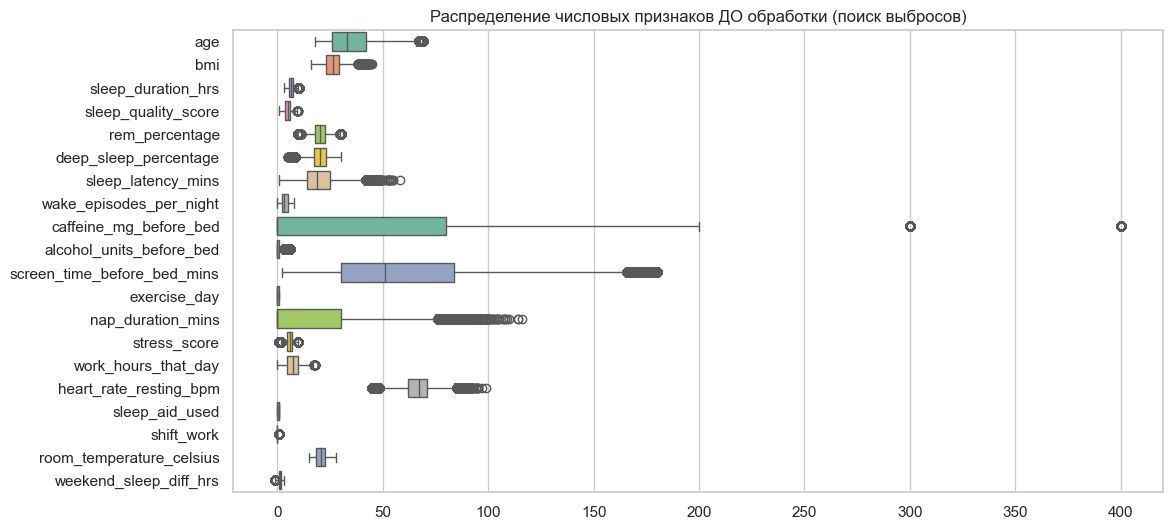

In [3]:
num_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns
num_cols =[c for c in num_cols if c not in['sleep_disorder_risk', 'cognitive_performance_score', 'felt_rested', 'person_id', 'steps_that_day']]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_raw[num_cols], orient='h', palette='Set2')
plt.title('Распределение числовых признаков ДО обработки (поиск выбросов)')
plt.show()

**Вывод:** Графики показывает, в почти всех числовых признаках присутствовуют аномальные значения. Чтобы они не сбивали обучение линейных моделей, обработаем их методом IQR в `preprocessing_pipeline`.

### 3. Обработка через Pipeline (Очистка + Feature Engineering)

In [5]:
df_processed = preprocess_pipeline(df_raw)
print(f"Размер после паплайна: {df_processed.shape}")
display(df_processed.info())

Размер после паплайна: (100000, 33)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   person_id                    100000 non-null  int64   
 1   age                          100000 non-null  int64   
 2   gender                       100000 non-null  str     
 3   occupation                   100000 non-null  str     
 4   bmi                          100000 non-null  float64 
 5   country                      100000 non-null  str     
 6   sleep_duration_hrs           100000 non-null  float64 
 7   sleep_quality_score          100000 non-null  float64 
 8   rem_percentage               100000 non-null  float64 
 9   deep_sleep_percentage        100000 non-null  float64 
 10  sleep_latency_mins           100000 non-null  float64 
 11  wake_episodes_per_night      100000 non-null  int64   
 12  caffeine_mg_before_b

None

**Вывод:** Были добавлены 3 новых признака (`deep_sleep_hours`, `sleep_stress_ratio`, `age_group`), которые должны помочь модели лучше улавливать нелинейные зависимости. Также были удалены лишние целевые переменные во избежание Data Leakage.

### 4.1. Распределение целевой переменной

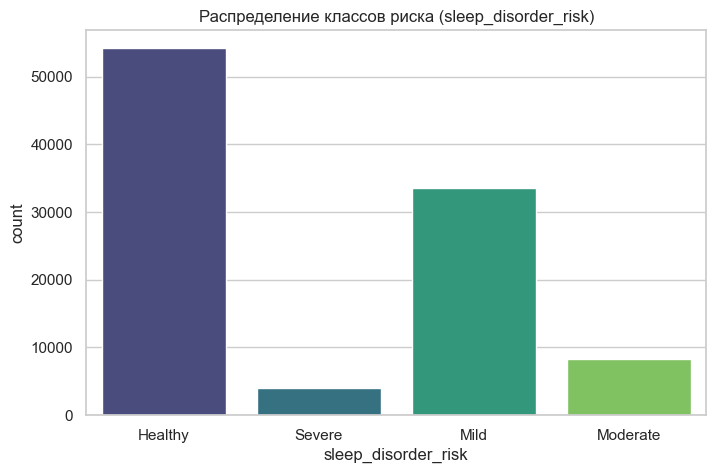

In [6]:
target_col = 'sleep_disorder_risk'

plt.figure(figsize=(8, 5))
# sns.countplot(data=df_processed, x=target_col, palette='viridis')
sns.countplot(data=df_processed, x=target_col, palette='viridis', hue=target_col, legend=False)
plt.title('Распределение классов риска (sleep_disorder_risk)')
plt.show()

 **Выбор метрики:** 
Распределение классов риска неравномерное, поэтому обычной метрики `Accuracy` будет недостаточно. Так как проект решает задачу мультиклассовой классификации, основной метрикой будет **F1-macro**.

### 4.2. Визуализация зависимостей (EDA)

C:\Users\Vasilisa\AppData\Local\Temp\ipykernel_25812\3970945326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x=target_col, y='sleep_stress_ratio', palette='Set1')


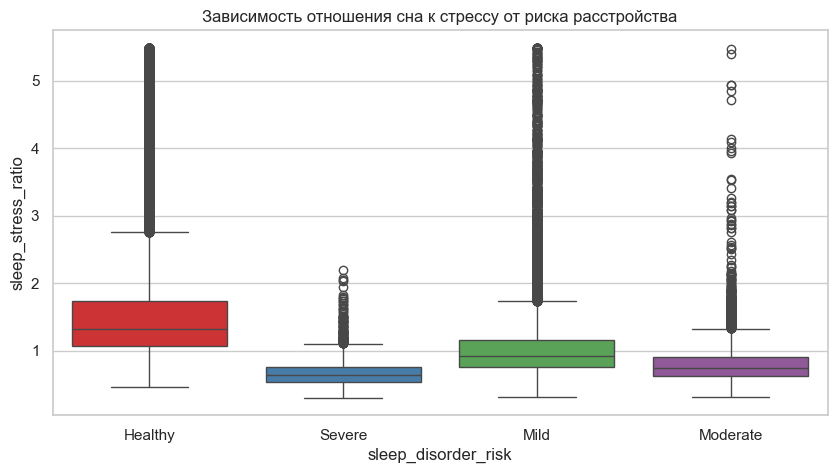

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_processed, x=target_col, y='sleep_stress_ratio', palette='Set1')
plt.title('Зависимость отношения сна к стрессу от риска расстройства')
plt.show()

**Вывод:** На графике видна сильная обратная зависимость между новым признаком `sleep_stress_ratio` и тяжестью риска расстройства сна. 
У здоровых людей (`Healthy`) медианное значение отношения сна к стрессу самое высокое — это значит, что они спят достаточно относительно своего уровня стресса. По мере ухудшения состояния по шкале риска (`Mild` -> `Moderate` -> `Severe`) этот показатель неуклонно падает, достигая минимума в группе `Severe`. То есть люди с тяжелым риском расстройств спят критически мало на фоне высокого стресса. 

Такая явная сепарация классов подтверждает, что придуманная фича обладает отличной предсказательной силой.

### 5. Оценка значимости признаков (Feature Importance)
Проверим, какие признаки больше всего влияют на таргет. Обучим простейший случайный лес на числовых признаках и выведем их важность.


C:\Users\Vasilisa\AppData\Local\Temp\ipykernel_25812\252145526.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


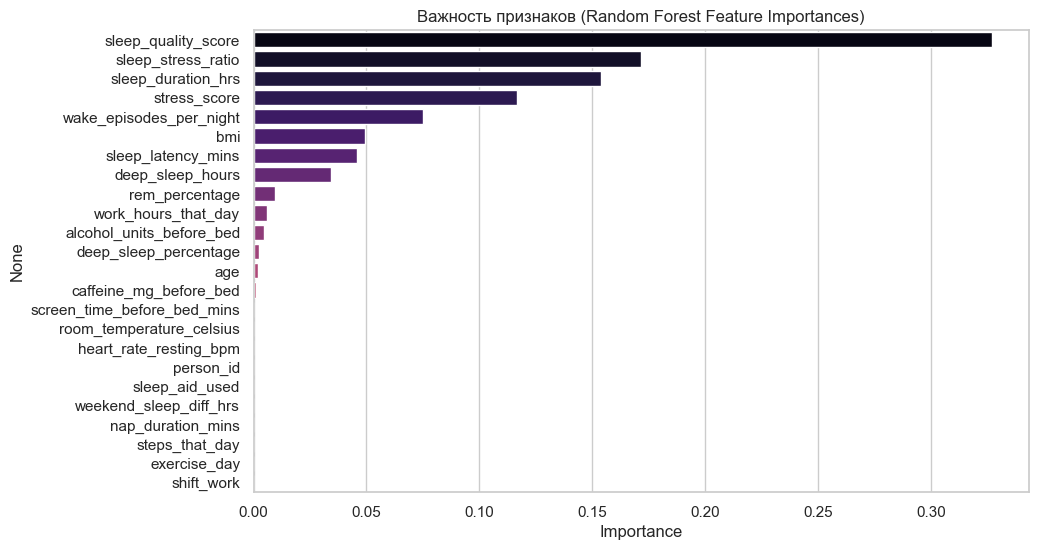

In [9]:
# Подготавливаем временный датафрейм только с числами для быстрого анализа важности
df_fi = df_processed.copy()

# Кодируем таргет в число
if df_fi[target_col].dtype == 'str':
    df_fi[target_col] = LabelEncoder().fit_transform(df_fi[target_col])

X_fi = df_fi.select_dtypes(include=['float64', 'int64']).drop(columns=[target_col])
y_fi = df_fi[target_col]

rf = RandomForestClassifier(random_state=RANDOM_STATE, max_depth=5)
rf.fit(X_fi, y_fi)

importances = pd.Series(rf.feature_importances_, index=X_fi.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Важность признаков (Random Forest Feature Importances)')
plt.xlabel('Importance')
plt.show()

**Вывод:** Анализ важности признаков показал очень интересные результаты:
1. Самым сильным предиктором оказался `sleep_quality_score` (оценка качества сна).
2. Новый сгенерированный признак `sleep_stress_ratio` занял **второе место** по значимости, обогнав исходные `sleep_duration_hrs` и `stress_score` по отдельности.
3. Еще одна новая фича `deep_sleep_hours` также вошла в топ-8 важнейших признаков.
4. Такие признаки как `person_id`, `shift_work` и `exercise_day` имеют практически нулевую важность для предсказания риска в данном датасете. В будущем их можно безболезненно удалить для упрощения модели.

### 6. Корректный сплит (Train / Val / Test)
Чтобы избежать Data Leakage, проводим разбиение ДО любого кодирования (OneHot) и стандартизации (StandardScaler).

Используем параметр `stratify`, чтобы во всех трех выборках сохранить одинаковые пропорции классов.

In [10]:
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Шаг 1: 70% на Train, 30% на временный сет (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Шаг 2: Временный сет бьем пополам -> 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Размер Train: {X_train.shape[0]} строк")
print(f"Размер Val:   {X_val.shape[0]} строк")
print(f"Размер Test:  {X_test.shape[0]} строк")

# Сохраняем в папку data/processed/ для следующего этапа (моделирования)
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

Размер Train: 70000 строк
Размер Val:   15000 строк
Размер Test:  15000 строк
